# 11. Real-World Problem Solving Using Supervised and Unsupervised Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Solve real-world problems
- Combine supervised and unsupervised learning
- Apply ML techniques
- Evaluate solutions
- Present results

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 4, lessons 02-10 (the full supervised and unsupervised toolkit) and Unit 1, lesson 07, which framed the same kind of problem before you could model it.

**Used later in:** Course 12 (AIAT 126) — Units 1 and 3, where this is the shape of the graduation project itself.

---

This notebook covers practical activities from **Course 05, Unit 4**:
- Real-world problem solving using a mix of supervised and unsupervised learning algorithms

---

## Introduction

**Real-world problem solving** often requires combining supervised and unsupervised learning techniques to address complex data science challenges effectively.


## 🎯 The case: what a model of a 1912 evacuation is, and is not

On the night of **15 April 1912** the RMS *Titanic* sank. Of roughly 2,200 people aboard,
about **1,500 died** and around **710 survivors** were picked up by the *Carpathia* — the
1912 British and American inquiries published different totals, and no single figure is
settled. Evacuation was governed by an
enforced "women and children first" order, and access to the boat deck depended on where
your cabin was — which depended on what you had paid.

That last sentence is why this notebook exists as a *whole project* rather than a modelling
exercise. You are about to segment 891 passengers without labels, then predict survival with
labels, and get **is_female +1.290** as the strongest coefficient. The number is correct. It
is a measurement of a **policy that was executed on a specific night**, not a property of
people, and not a rule that transfers anywhere.

**What goes wrong without that discipline.** A model that reports "class 1 passengers
survived more" gets read as "wealth causes survival". The mechanism was physical — deck
position, distance to a lifeboat, the order in which stewards unlocked gates. Sculley et al.
(*Hidden Technical Debt in Machine Learning Systems*, NeurIPS 2015) made the general point:
the model is a small box inside a much larger system, and almost everything that determines
whether the box is useful lives outside it.

Every project you ship will have this shape. The arithmetic will be right. The question is
whether the sentence you write underneath it is.


## The Story

**BEFORE**: You know individual ML techniques but haven't applied them to solve complete real-world problems.

**AFTER**: You'll solve a complete real-world problem: from data to model to evaluation - end-to-end ML project!

**Why this matters**: Real-World Problem Solving Using Supervised and Unsupervised Learning is essential for building complete, professional data science solutions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `titanic.csv` — the 891-passenger manifest of the RMS Titanic,
  with 177 genuinely missing ages and fares spanning £0 to £512.33.
- sklearn (KMeans, LogisticRegression, StandardScaler), pandas, matplotlib

**Outputs:** What you'll see when you run the cells

- Passenger segments discovered without labels, then a survival model built with them
- Segment-by-segment survival rates and ranked model coefficients — all computed here

---


In [1]:
# WHAT: Import tools and lay out the project plan - segment the passengers, then predict survival.
# WHY: Real problems combine techniques; this mini-project chains an unsupervised and a supervised step.

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

print("✅ Libraries imported!")
print("\nReal-World Problem Solving: End-to-End Mini Project")
print("=" * 60)
print("""
The question: the RMS Titanic sank on 15 April 1912 with 891 passengers on
the recorded manifest. Two things a historian (or a modern safety analyst)
would want to know:
  1. WHO was on board? - SEGMENT the passengers (unsupervised, no labels needed)
  2. WHO survived, and why? - PREDICT survival (supervised, labelled outcome)

Plan: data -> explore -> K-Means segments -> survival model -> insights
Every number below comes from the real manifest.
""")

✅ Libraries imported!

Real-World Problem Solving: End-to-End Mini Project

The question: the RMS Titanic sank on 15 April 1912 with 891 passengers on
the recorded manifest. Two things a historian (or a modern safety analyst)
would want to know:
  1. WHO was on board? - SEGMENT the passengers (unsupervised, no labels needed)
  2. WHO survived, and why? - PREDICT survival (supervised, labelled outcome)

Plan: data -> explore -> K-Means segments -> survival model -> insights
Every number below comes from the real manifest.



## Step 1: The Data

The real RMS Titanic passenger manifest (891 rows, a public historical record).
`Survived` is our supervised label; everything else describes who the passenger was.
177 ages are genuinely missing — we fill them with the median and say so.


In [2]:
# WHAT: Load the real Titanic manifest and derive the three behaviour features we cluster on.
# WHY: This is a historical record, not a simulation - the signal the model finds is a fact
#      about 1912, and we can check the model against what historians already know.

print("Step 1: Load and explore the data")
print("-" * 60)

DATA_DIR = '../../../Course 04/datasets/raw/'
passengers = pd.read_csv(DATA_DIR + 'titanic.csv')

n = len(passengers)
n_missing_age = passengers['Age'].isna().sum()
passengers['Age'] = passengers['Age'].fillna(passengers['Age'].median())
passengers['family_size'] = passengers['SibSp'] + passengers['Parch'] + 1
passengers['is_female'] = (passengers['Sex'] == 'female').astype(int)

print(passengers[['Name', 'Pclass', 'Sex', 'Age', 'Fare',
                  'family_size', 'Survived']].head().to_string())
print(f"\n{n} passengers on the manifest, overall survival rate: "
      f"{passengers['Survived'].mean():.1%}")
print(f"Missing ages filled with the median: {n_missing_age} "
      f"({n_missing_age / n:.1%} of the manifest)")
print("\nSummary statistics:")
print(passengers[['Age', 'Fare', 'family_size', 'Pclass', 'Survived']]
      .describe().round(2).to_string())

Step 1: Load and explore the data
------------------------------------------------------------
                                                  Name  Pclass     Sex   Age     Fare  family_size  Survived
0                              Braund, Mr. Owen Harris       3    male  22.0   7.2500            2         0
1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)       1  female  38.0  71.2833            2         1
2                               Heikkinen, Miss. Laina       3  female  26.0   7.9250            1         1
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)       1  female  35.0  53.1000            2         1
4                             Allen, Mr. William Henry       3    male  35.0   8.0500            1         0

891 passengers on the manifest, overall survival rate: 38.4%
Missing ages filled with the median: 177 (19.9% of the manifest)

Summary statistics:
          Age    Fare  family_size  Pclass  Survived
count  891.00  891.00       891.00  891.00    891.

## Step 2: Unsupervised — Passenger Segments with K-Means

No labels here: we cluster on who the passengers *were* (age, fare paid, family
size) to find natural groups. The survival label is deliberately withheld from
the clustering step, so any survival difference between segments is a discovery,
not something we built in.


Step 2: K-Means passenger segmentation
------------------------------------------------------------
Segment profiles (means):
           Age    Fare  family_size  Pclass  is_female  Survived  size
segment                                                               
0        34.93  207.09         2.54    1.00       0.66      0.73    41
1        31.62   21.93         1.37    2.33       0.31      0.35   728
2        13.99   34.75         4.87    2.62       0.51      0.45   122


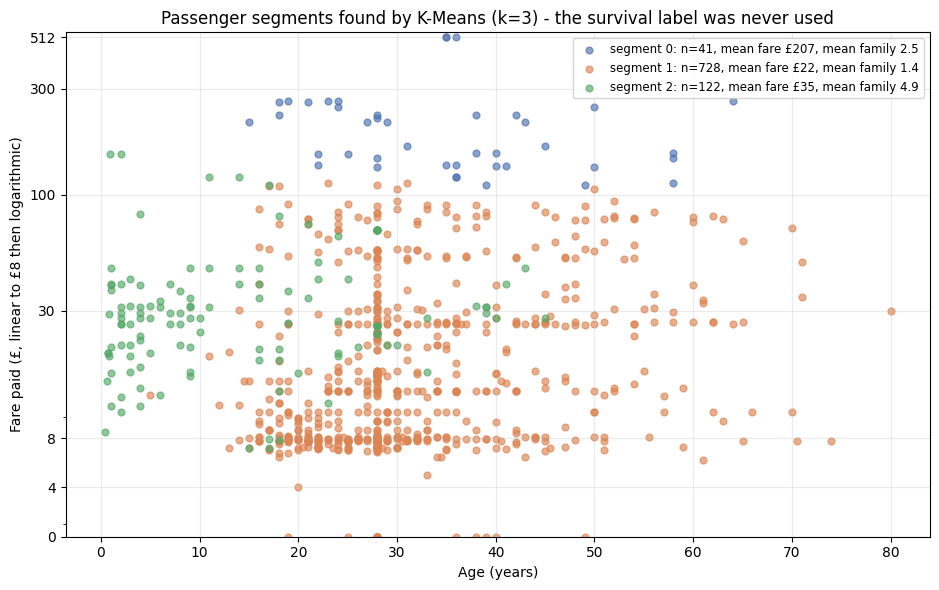

✓ Segments plotted - each colour is a discovered passenger group
  (the fare axis is linear to £8 and logarithmic above: median fare £14, maximum £512,
   and it stops at £0 because a negative fare does not exist)


In [3]:
# WHAT: Standardize three descriptive features and segment passengers with K-Means (k=3).
# WHY: Scaling first is essential - otherwise Fare (0-512) would drown out family_size (1-11).

print("Step 2: K-Means passenger segmentation")
print("-" * 60)

seg_features = ['Age', 'Fare', 'family_size']
scaler_seg = StandardScaler()
X_seg = scaler_seg.fit_transform(passengers[seg_features])

# NOTE: 'Survived' is NOT in seg_features. The clustering never sees the outcome.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
passengers['segment'] = kmeans.fit_predict(X_seg)

profile = passengers.groupby('segment')[seg_features + ['Pclass', 'is_female', 'Survived']].mean().round(2)
profile['size'] = passengers['segment'].value_counts().sort_index()
print("Segment profiles (means):")
print(profile.to_string())

# Segment is a label, not a quantity - so three named series, not a colour bar. And the
# fare axis is clipped to [0, max]: a symlog axis that runs below zero draws a wide empty
# band where no fare can exist.
SEG_COLOURS = ['#4c72b0', '#dd8452', '#55a868']
fig, ax = plt.subplots(figsize=(9.5, 6))
for s in sorted(passengers['segment'].unique()):
    m = passengers['segment'] == s
    ax.scatter(passengers.loc[m, 'Age'], passengers.loc[m, 'Fare'],
               s=24, alpha=0.65, color=SEG_COLOURS[s],
               label=f"segment {s}: n={int(m.sum())}, mean fare £{profile.loc[s, 'Fare']:.0f}, "
                     f"mean family {profile.loc[s, 'family_size']:.1f}")
ax.set_yscale('symlog', linthresh=8, linscale=0.4)
ax.set_ylim(0, passengers['Fare'].max() * 1.05)
ax.set_yticks([0, 4, 8, 30, 100, 300, 512])
ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_title('Passenger segments found by K-Means (k=3) - the survival label was never used')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Fare paid (£, linear to £8 then logarithmic)')
ax.legend(loc='upper right', fontsize=8.5)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print("✓ Segments plotted - each colour is a discovered passenger group")
print("  (the fare axis is linear to £8 and logarithmic above: median fare £14, maximum £512,")
print("   and it stops at £0 because a negative fare does not exist)")

**Read the figure.** Age across, fare paid up the side, one colour per discovered segment —
and the survival column was never shown to K-Means. The legend is the story of what it found.
**Segment 0** (blue, n=41) is defined by fare: mean £207, and it owns the top of the plot alone.
**Segment 1** (orange, n=728) is the bulk of the manifest, mean fare £22, filling the cheap band
across every age. **Segment 2** (green, n=122) is concentrated on the **left**: mean age 14, mean
family size 4.9 — children travelling with families. Notice that green and orange overlap almost
completely on the fare axis; what separates them here is age, and their third distinguishing
feature, family size, is a dimension this two-axis view cannot show at all. A 2-D picture of a
3-D clustering always hides one axis, which is why the printed segment profile above the figure
is not optional reading.

## Step 3: Supervised — Predict Survival

Now we use the labeled outcome (`Survived`) to train a classifier on the full
feature set, and read its standardized coefficients to see which characteristics
mattered most.


In [4]:
# WHAT: Train a survival classifier and rank its standardized coefficients.
# WHY: On standardized features, coefficient size is comparable - it reveals which
#      characteristics mattered most, and in which direction.

print("Step 3: Survival prediction with logistic regression")
print("-" * 60)

features = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'is_female', 'family_size']
X = passengers[features]
y = passengers['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

survival_model = LogisticRegression(max_iter=1000)
survival_model.fit(X_train_s, y_train)
y_pred = survival_model.predict(X_test_s)
acc = accuracy_score(y_test, y_pred)
baseline = max(y_test.mean(), 1 - y_test.mean())

print(f"Test accuracy: {acc:.2%}   (majority-class baseline: {baseline:.2%})")
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3,
                            target_names=['died', 'survived']))

print("Model coefficients (standardized features -> comparable):")
coef_order = sorted(zip(features, survival_model.coef_[0]),
                    key=lambda t: abs(t[1]), reverse=True)
for name, c in coef_order:
    direction = "raises" if c > 0 else "lowers"
    print(f"  {name:12s} {c:+.3f}  ({direction} survival odds)")

Step 3: Survival prediction with logistic regression
------------------------------------------------------------
Test accuracy: 78.03%   (majority-class baseline: 61.43%)

Classification report:
              precision    recall  f1-score   support

        died      0.824     0.818     0.821       137
    survived      0.713     0.721     0.717        86

    accuracy                          0.780       223
   macro avg      0.768     0.769     0.769       223
weighted avg      0.781     0.780     0.781       223

Model coefficients (standardized features -> comparable):
  is_female    +1.290  (raises survival odds)
  Pclass       -0.899  (lowers survival odds)
  Age          -0.523  (lowers survival odds)
  SibSp        -0.196  (lowers survival odds)
  Fare         +0.173  (raises survival odds)
  family_size  -0.124  (lowers survival odds)
  Parch        +0.008  (raises survival odds)


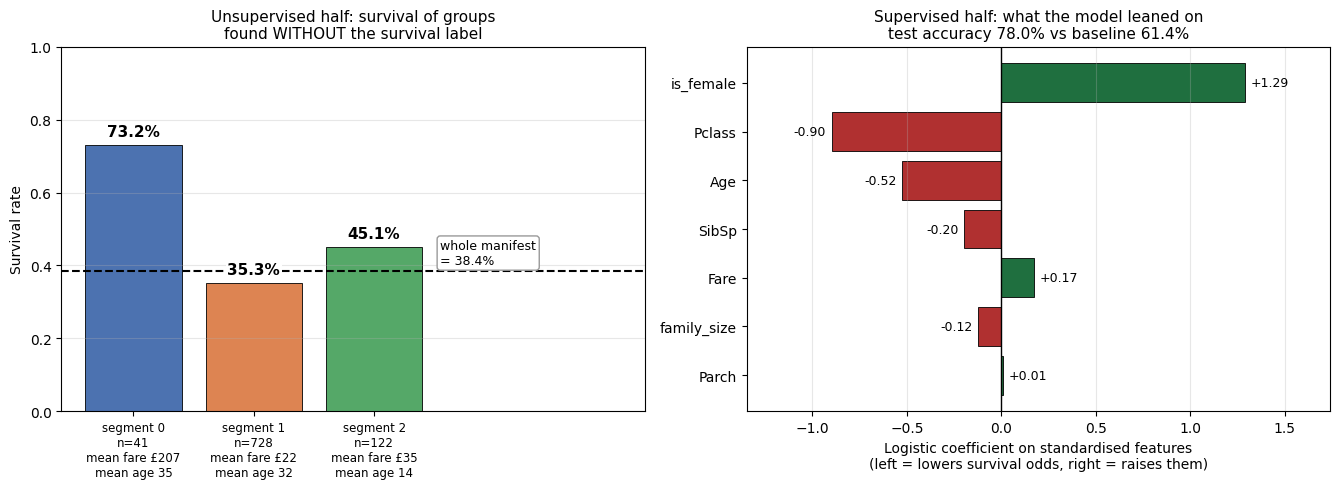

Segment survival rates: segment 0 73.2% (n=41), segment 1 35.3% (n=728), segment 2 45.1% (n=122)
Whole manifest: 38.4%
Largest coefficient: is_female (+1.290); smallest: Parch (+0.008)


In [5]:
# WHAT: Put the two halves of this mini-project side by side - what the unsupervised segments
#       turned out to be worth, and what the supervised model says drove survival.
# WHY: The summary below states both results as sentences. They are the project's answer, so
#      they deserve to be legible at a glance rather than read off a paragraph.
seg_survival = passengers.groupby('segment')['Survived'].mean()
seg_sizes = passengers['segment'].value_counts().sort_index()
overall = passengers['Survived'].mean()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5))

# LEFT - unsupervised half: did the blind segments differ in outcome?
positions = list(range(len(seg_survival)))
bars = axL.bar(positions, seg_survival.values,
               color=SEG_COLOURS, edgecolor='black', linewidth=0.6)
for b, s in zip(bars, seg_survival.index):
    axL.text(b.get_x() + b.get_width() / 2, seg_survival[s] + 0.015,
             f"{seg_survival[s]:.1%}", ha='center', va='bottom', fontsize=11, weight='bold',
             bbox=dict(boxstyle='square,pad=0.12', facecolor='white', edgecolor='none'))
axL.set_xticks(positions)
# Four short stacked lines per tick - long single lines run into each other.
axL.set_xticklabels([f"segment {s}\nn={int(seg_sizes[s])}\nmean fare "
                     f"£{profile.loc[s, 'Fare']:.0f}\nmean age {profile.loc[s, 'Age']:.0f}"
                     for s in seg_survival.index], fontsize=8.5)
axL.axhline(overall, color='black', linestyle='--', linewidth=1.5)
# Keep clear space to the right of the bars so the reference line can be labelled cleanly.
axL.set_xlim(-0.6, len(seg_survival) - 0.1 + 1.35)
axL.text(len(seg_survival) - 0.45, overall + 0.02,
         f"whole manifest{chr(10)}= {overall:.1%}", ha='left', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.6'))
axL.set_ylim(0, 1.0)
axL.set_ylabel('Survival rate')
axL.set_title('Unsupervised half: survival of groups\nfound WITHOUT the survival label',
              fontsize=11)
axL.grid(axis='y', alpha=0.3)

# RIGHT - supervised half: which standardised coefficients moved the odds, and which way?
names = [n for n, _ in coef_order][::-1]
vals = [c for _, c in coef_order][::-1]
colours = ['#1f6f3f' if v > 0 else '#b03030' for v in vals]
axR.barh(names, vals, color=colours, edgecolor='black', linewidth=0.6)
for i, v in enumerate(vals):
    axR.text(v + (0.03 if v > 0 else -0.03), i, f"{v:+.2f}",
             va='center', ha='left' if v > 0 else 'right', fontsize=9)
axR.axvline(0, color='black', linewidth=1)
axR.set_xlim(min(vals) - 0.45, max(vals) + 0.45)
axR.set_xlabel('Logistic coefficient on standardised features\n(left = lowers survival odds, '
               'right = raises them)')
axR.set_title(f'Supervised half: what the model leaned on\n'
              f'test accuracy {acc:.1%} vs baseline {baseline:.1%}', fontsize=11)
axR.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Segment survival rates: "
      f"{', '.join(f'segment {s} {r:.1%} (n={int(seg_sizes[s])})' for s, r in seg_survival.items())}")
print(f"Whole manifest: {overall:.1%}")
print(f"Largest coefficient: {coef_order[0][0]} ({coef_order[0][1]:+.3f}); "
      f"smallest: {coef_order[-1][0]} ({coef_order[-1][1]:+.3f})")


**Read the figure.** The two halves of the project, side by side.

**Left — the unsupervised half.** Three bars, one per K-Means segment, with the survival rate of
each and the whole manifest's 38.4% ruled across as a dashed line. The segments were built from
age, fare and family size only; survival was never in the input. Yet they come out at **73.2%,
35.3% and 45.1%** — the small high-fare segment survived at roughly twice the rate of the large
cheap-fare one. Clustering that never saw the outcome still landed on groups whose outcomes
differ sharply, which is the point of running the unsupervised step at all.

**Right — the supervised half.** The logistic model's coefficients on standardised features, so
their lengths are comparable, with green bars raising the survival odds and red bars lowering
them. One bar dwarfs the rest: **is_female, +1.29**. Next come **Pclass −0.90** (a higher class
number means a cheaper deck, further from the boats) and **Age −0.52**. `Fare` gets only **+0.17**
because `Pclass` has already absorbed most of what fare encodes, and `Parch` at **+0.01** is doing
nothing at all.

Read the two panels together and they agree without being the same statement: the clustering
found wealth-shaped groups with different survival, and the model says the single strongest
recorded predictor was not wealth but sex. Both are descriptions of an evacuation in which "women
and children first" was enforced and deck position was set by ticket class — a historical policy,
not a rule for any decision today.

In [6]:
# WHAT: Combine segments and model into computed insights and a summary.
# WHY: The answer is the intersection: WHICH groups survived, and WHY.

print("=" * 60)
print("Step 4: Insights & Summary")
print("=" * 60)

seg_survival = passengers.groupby('segment')['Survived'].mean()
best = seg_survival.idxmax()
worst = seg_survival.idxmin()
top_driver = coef_order[0][0]
print(f"""
End-to-end project - what the real 1912 manifest told us (all computed above):
  - Survival rate by segment: {', '.join(f'segment {s}: {r:.1%}' for s, r in seg_survival.items())}
  - Highest-surviving segment: {best} ({seg_survival[best]:.1%}) - mean fare
    £{profile.loc[best, 'Fare']:.0f}, mean age {profile.loc[best, 'Age']:.0f}, mean class {profile.loc[best, 'Pclass']:.1f}
  - Lowest-surviving segment: {worst} ({seg_survival[worst]:.1%}) - mean fare
    £{profile.loc[worst, 'Fare']:.0f}, mean age {profile.loc[worst, 'Age']:.0f}, mean class {profile.loc[worst, 'Pclass']:.1f}
  - Strongest survival driver in the model: {top_driver} ({coef_order[0][1]:+.3f})
  - Survival model test accuracy: {acc:.2%} (baseline {baseline:.2%})

The full workflow we just executed:
  1. Data collection & exploration (pandas) on a real historical record
  2. Unsupervised segmentation (K-Means) - the outcome label was withheld
  3. Supervised prediction (logistic regression) - labelled outcome used
  4. Insights that combine both: which SEGMENTS survived, and which
     characteristics the model says explain it

⚠️  Read the result carefully. The model is describing a 1912 evacuation in which
   "women and children first" was enforced and lifeboat access depended on deck
   position, which depended on ticket class. The coefficients report that
   historical reality; they are not a rule for any decision today.

Next: Example 12 asks what happens to this workflow when data
gets much bigger - CPU vs GPU for ML.
""")
print("✅ End-to-end real-world problem solving - complete!")

Step 4: Insights & Summary

End-to-end project - what the real 1912 manifest told us (all computed above):
  - Survival rate by segment: segment 0: 73.2%, segment 1: 35.3%, segment 2: 45.1%
  - Highest-surviving segment: 0 (73.2%) - mean fare
    £207, mean age 35, mean class 1.0
  - Lowest-surviving segment: 1 (35.3%) - mean fare
    £22, mean age 32, mean class 2.3
  - Strongest survival driver in the model: is_female (+1.290)
  - Survival model test accuracy: 78.03% (baseline 61.43%)

The full workflow we just executed:
  1. Data collection & exploration (pandas) on a real historical record
  2. Unsupervised segmentation (K-Means) - the outcome label was withheld
  3. Supervised prediction (logistic regression) - labelled outcome used
  4. Insights that combine both: which SEGMENTS survived, and which
     characteristics the model says explain it

⚠️  Read the result carefully. The model is describing a 1912 evacuation in which
   "women and children first" was enforced and lifeboa

## ⚠️ Where this breaks

- **The model measures a historical policy, not a mechanism.** "Women and children first"
  was enforced; ticket class determined deck position and therefore distance to a boat. The
  coefficients report the outcome of those two facts. Nothing here supports a causal claim,
  and nothing here transfers to a different ship, a different era, or a different policy.
- **The pipeline runs on 891 records with 177 imputed ages.** Every downstream number
  inherits that. Lesson 02 measured the cost: mean-imputing `Age` shrinks its standard
  deviation from 14.53 to 13.00, so the model's uncertainty is understated by construction.
- **Clustering before modelling can leak if you are careless.** It did not here — the
  survival label was withheld from the segmentation, which is exactly why the segment
  survival gap is meaningful. Cluster on the target, or on anything derived from it, and the
  "discovery" is your own label handed back to you.
- **A 3-segment solution is a choice, not a finding.** Lesson 09 showed silhouette voting for
  the wrong k on data where the truth was known. Here nobody knows the truth, so k=3 is a
  decision that shaped every segment number above it.
- **The assumption that must hold: the manifest is the population.** These 891 records are
  the passengers whose details survived into the public dataset, out of roughly 2,200 people
  aboard. Any rate computed here is a rate among *the recorded*, and record-keeping in 1912
  was not uniform across classes.
- **78.03% accuracy against a 61.43% baseline is a 16-point gain on 223 test passengers.**
  Roughly 37 passengers separate the two. Report a cross-validated interval before anyone
  quotes the number.
- **Cheaper alternative:** for a historical question, a well-chosen cross-tabulation
  (Unit 3 lesson 03 produced the whole story in six numbers) is more defensible and more
  readable than a model. Build the model when you need to *predict* a case you have not
  seen — and here, there are no more cases.


## 💬 Discuss

The end-to-end project produced: three unsupervised segments with survival rates **73.2%
(n=41, mean fare £207)**, **35.3% (n=728, mean fare £22)** and **45.1% (n=122, mean age
14.0, mean family size 4.87)**; and a model scoring **78.03%** against a **61.43%** baseline
with **is_female +1.290, Pclass −0.899, Age −0.523**.

1. The clustering never saw the `Survived` column, so the 73.2% / 35.3% / 45.1% gap is a
   genuine discovery rather than something built in. Explain to a sceptical colleague why
   that ordering matters — and name the mistake that would have destroyed the claim.
2. Segment 2 has mean age **14.0** and mean family size **4.87** — children travelling with
   families — and a middling survival rate of 45.1%. Given "women and children first", why
   is it not higher? Propose an explanation, then say which column in the manifest would let
   you test it.
3. The notebook ends by warning that these coefficients describe a 1912 evacuation and are
   not a rule for any decision today. Now suppose a maritime regulator asks you to use this
   model to design lifeboat allocation. Write the two sentences you would say. What would you
   need instead — data, or something else?


## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Domingos, P. (2012). *A Few Useful Things to Know About Machine Learning*. Communications of the ACM, 55(10), 78-87. <https://doi.org/10.1145/2347736.2347755>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed. Springer. <https://www.statlearning.com>
4. Jing, L., Huang, Z., Wang, X., et al. (2024). *DSBench: How Far Are Data Science Agents from Becoming Data Science Experts?*. arXiv:2409.07703. <https://arxiv.org/abs/2409.07703>
5. Chen, K., Wang, P., Yu, Y., Zhan, X., & Wang, H. (2025). *Large Language Model-based Data Science Agent: A Survey*. arXiv:2508.02744. <https://arxiv.org/abs/2508.02744>
